<a href="https://colab.research.google.com/github/cheecaixi/AISDPJ/blob/main/AISDPJ_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Load Dataset**



In [24]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load the dataset from the SQLite database
conn = sqlite3.connect("gas_monitoring.db")
df = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)
conn.close()


# **Dataset Overview**



In [26]:
# Preview the first 5 rows
display(df.head())

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [27]:
# Column names and data types
print(df.dtypes)

Time of Day                   object
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode           object
Ambient Light Level           object
Activity Level                object
dtype: object


In [28]:
# Summary statistics for numerical columns
display(df.describe())

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


In [29]:
# Unique values in categorical columns
categorical_cols = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level", "Activity Level"]

for col in categorical_cols:
    display(df[col].value_counts(dropna=False))

,count
Time of Day,
afternoon,2635
evening,2476
morning,2460
night,2429


,count
HVAC Operation Mode,
cooling_active,1502
maintenance_mode,1500
heating_active,1468
off,1456
eco_mode,1452
ventilation_only,1394
COOLING_ACTIVE,112
ECO_MODE,112
MAINTENANCE_MODE,106


,count
Ambient Light Level,
very_bright,3387
bright,2697
moderate,1463
None,1054
dim,864
very_dim,535


,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238



# **Cleaning Dataset**



In [32]:
# Convert all text to lowercase and unify spacing/underscores
def standardise_text(series):
    return (
        series
        .str.strip()
        .str.lower()
        .str.replace(r"[\s_]+", "_", regex=True)
    )

text_cols = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level", "Activity Level"]
for col in text_cols:
    df[col] = standardise_text(df[col])

In [33]:
# Standardise Activity Level labels
activity_map = {
    "low_activity": "Low Activity",
    "lowactivity":  "Low Activity",
    "moderate_activity": "Moderate Activity",
    "moderateactivity":  "Moderate Activity",
    "high_activity": "High Activity",
}
df["Activity Level"] = df["Activity Level"].map(activity_map)


In [34]:
# Standardise HVAC Operation Mode labels
hvac_map = {
    "off": "Off",
    "eco_mode": "Eco Mode",
    "ventilation_only": "Ventilation Only",
    "heating_active": "Heating Active",
    "cooling_active": "Cooling Active",
    "maintenance_mode": "Maintenance Mode",
}
df["HVAC Operation Mode"] = df["HVAC Operation Mode"].map(hvac_map)

In [35]:
# Standardise Ambient Light Level labels
light_map = {
    "very_dim": "Very Dim",
    "dim": "Dim",
    "moderate": "Moderate",
    "bright": "Bright",
    "very_bright": "Very Bright",
}
df["Ambient Light Level"] = df["Ambient Light Level"].map(light_map)

In [36]:
# Assumption: valid indoor temperature is between 10°C and 40°C
# Instead of deleting the rows with missing cells, NaN is being replaced in the cell
df.loc[(df["Temperature"] < 10) | (df["Temperature"] > 40), "Temperature"] = np.nan

In [38]:
display(df)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,Off,Very Dim,Low Activity
1,morning,NaN,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,Ventilation Only,Bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,Eco Mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,Eco Mode,Very Bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,Heating Active,Moderate,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,Maintenance Mode,Very Bright,Low Activity
9996,evening,NaN,46.98,131.945968,541.756022,517.719693,738.901193,689.383365,625.100827,2.0,2586,Ventilation Only,Very Dim,Low Activity
9997,evening,23.71,49.16,136.422868,542.072190,512.607291,732.456099,683.197988,622.035384,2.0,2586,Eco Mode,Very Bright,Low Activity
9998,night,20.58,NaN,126.734430,561.716292,435.638480,707.447312,648.634308,581.583550,1.0,4761,Cooling Active,Very Bright,Low Activity



# **Missing Value Analysis**



In [39]:
# Count missing values per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %":     missing_pct
})

print(missing_summary[missing_summary["Missing Count"] > 0])

                        Missing Count  Missing %
Temperature                       864       8.64
Humidity                         1928      19.28
MetalOxideSensor_Unit2           1410      14.10
CO_GasSensor                      834       8.34
Ambient Light Level              1054      10.54


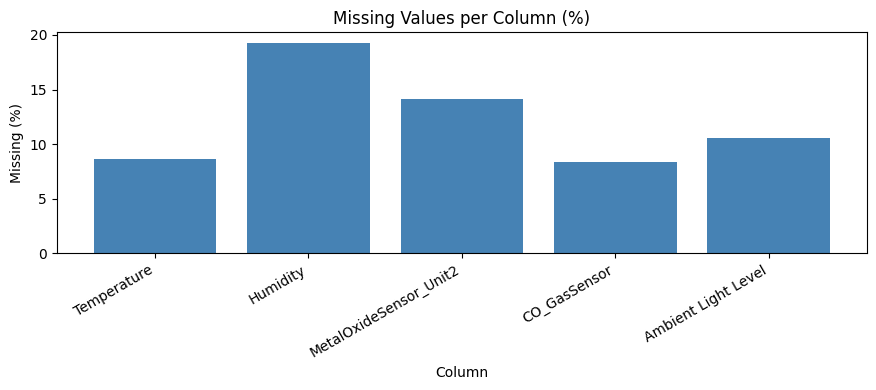

In [40]:
# Visualise missing values as a bar chart
missing_to_plot = missing_summary[missing_summary["Missing Count"] > 0]

plt.figure(figsize=(9, 4))
plt.bar(missing_to_plot.index, missing_to_plot["Missing %"], color="steelblue")
plt.title("Missing Values per Column (%)")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Four columns were found to have missing values:
- Humidity (19.3%)
- MetalOxideSensor_Unit2 (14.1%)
- Ambient Light Level (10.5%)
- CO_GasSensor (8.3%).

For numerical columns, missing values will be imputed using the median per Session ID, as the median is more robust to outliers than the mean. For the categorical column, Ambient Light Level, the mode per Session ID will be used, as lighting conditions tend to stay consistent within a session.